# 67. The Kitting & Value-Added Service Scheduling Problem
## Tier 2: The Classic Heuristic (Python Implementation)

### Key Assumptions
- Priority-based scheduling using cost-effectiveness ratios
- Real-time decision making with limited computational resources
- Greedy approach with lookahead capability
- Demand urgency and resource availability considered

### Approach (Step-by-Step)
1. **Calculate Priority Scores**: Compute cost savings per processing time for each kit-shift combination
2. **Sort by Priority**: Rank all possible kitting operations by priority score
3. **Greedy Assignment**: Assign highest priority operations first respecting capacity constraints
4. **Update Resources**: Track remaining capacity and inventory after each assignment
5. **Iterate Until Complete**: Continue until all demand is satisfied or capacity is exhausted

### What to Look For in the Results
- Priority calculations and ranking of kitting operations
- Real-time scheduling performance vs optimal solution
- Computational efficiency and scalability
- Trade-offs between speed and solution quality

### Concrete Example (from the source)
We'll implement the WSPT-KP heuristic with 3 kits and 2 shifts:
- Kit 1: 5 min processing, $2.50 cost savings per unit
- Kit 2: 8 min processing, $4.00 cost savings per unit
- Kit 3: 3 min processing, $1.80 cost savings per unit
- Shift 1 capacity: 480 minutes, Shift 2 capacity: 420 minutes
- Demands: Kit 1 = 60 units, Kit 2 = 40 units, Kit 3 = 80 units

In [1]:
# Import required libraries for heuristic implementation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import heapq
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
import time

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
@dataclass
class KittingOperation:
    """Represents a potential kitting operation with priority score"""
    kit_id: int
    shift_id: int
    period_id: int
    processing_time: float
    cost_savings: float
    demand_urgency: float
    priority_score: float
    
    def __lt__(self, other):
        """For priority queue (higher priority first)"""
        return self.priority_score > other.priority_score

@dataclass
class HeuristicProblem:
    """Data structure for heuristic kitting problem"""
    num_kits: int
    num_shifts: int
    num_periods: int
    
    # Problem parameters
    processing_times: np.ndarray  # [kit]
    cost_savings: np.ndarray     # [kit]
    demand: np.ndarray          # [kit][period]
    capacities: np.ndarray      # [shift][period]
    labor_costs: np.ndarray     # [shift][period]
    
    # Heuristic parameters
    urgency_weights: np.ndarray = field(default_factory=lambda: np.array([1.0, 0.8, 0.6]))
    setup_time: float = 1.0  # Setup time per kit type

def create_heuristic_example():
    """Create the example problem from the source material"""
    return HeuristicProblem(
        num_kits=3,
        num_shifts=2,
        num_periods=1,
        
        # Processing times per kit (minutes)
        processing_times=np.array([5, 8, 3]),
        
        # Cost savings per kit ($)
        cost_savings=np.array([2.50, 4.00, 1.80]),
        
        # Demand matrix [kit][period]
        demand=np.array([
            [60],  # Kit 1 demand
            [40],  # Kit 2 demand
            [80]   # Kit 3 demand
        ]),
        
        # Capacity matrix [shift][period]
        capacities=np.array([
            [480],  # Shift 1 capacity
            [420]   # Shift 2 capacity
        ]),
        
        # Labor costs [shift][period]
        labor_costs=np.array([
            [15.0],  # Shift 1 cost per hour
            [18.0]   # Shift 2 cost per hour
        ])
    )

# Create the problem instance
problem = create_heuristic_example()
print(f"Heuristic problem created: {problem.num_kits} kits, {problem.num_shifts} shifts, {problem.num_periods} periods")

Heuristic problem created: 3 kits, 2 shifts, 1 periods


In [3]:
def calculate_priority_score(kit_id: int, shift_id: int, period_id: int, 
                           problem: HeuristicProblem) -> float:
    """Calculate priority score using WSPT-KP methodology"""
    
    # Basic cost-effectiveness ratio
    processing_time = problem.processing_times[kit_id] + problem.setup_time
    cost_savings = problem.cost_savings[kit_id]
    base_ratio = cost_savings / processing_time
    
    # Demand urgency factor (higher for earlier periods)
    urgency_factor = problem.urgency_weights[min(period_id, len(problem.urgency_weights)-1)]
    
    # Labor cost adjustment (prefer lower cost shifts)
    max_labor_cost = np.max(problem.labor_costs)
    labor_adjustment = max_labor_cost / problem.labor_costs[shift_id, period_id]
    
    # Capacity utilization factor (prefer underutilized shifts)
    total_capacity = np.sum(problem.capacities[:, period_id])
    shift_capacity_ratio = problem.capacities[shift_id, period_id] / total_capacity
    capacity_factor = 1.0 / (1.0 + shift_capacity_ratio)  # Inverse to prefer underutilized shifts
    
    # Combined priority score
    priority_score = base_ratio * urgency_factor * labor_adjustment * capacity_factor
    
    return priority_score

def generate_priority_queue(problem: HeuristicProblem) -> List[KittingOperation]:
    """Generate all possible kitting operations with priority scores"""
    
    operations = []
    
    for kit_id in range(problem.num_kits):
        for shift_id in range(problem.num_shifts):
            for period_id in range(problem.num_periods):
                if problem.demand[kit_id, period_id] > 0:  # Only if there's demand
                    priority_score = calculate_priority_score(kit_id, shift_id, period_id, problem)
                    
                    operation = KittingOperation(
                        kit_id=kit_id,
                        shift_id=shift_id,
                        period_id=period_id,
                        processing_time=problem.processing_times[kit_id],
                        cost_savings=problem.cost_savings[kit_id],
                        demand_urgency=problem.urgency_weights[min(period_id, len(problem.urgency_weights)-1)],
                        priority_score=priority_score
                    )
                    
                    operations.append(operation)
    
    # Sort by priority score (descending)
    operations.sort(key=lambda x: x.priority_score, reverse=True)
    
    return operations

# Generate and display priority calculations
operations = generate_priority_queue(problem)

print("Priority Calculations for All Operations:")
print("=" * 80)
print(f"{'Kit':<6} {'Shift':<8} {'Period':<10} {'Proc Time':<12} {'Cost Sav':<10} {'Priority':<12}")
print("=" * 80)

for op in operations:
    print(f"{op.kit_id+1:<6} {op.shift_id+1:<8} {op.period_id+1:<10} {op.processing_time:<12.1f} "
          f"${op.cost_savings:<9.2f} {op.priority_score:<12.4f}")

Priority Calculations for All Operations:
Kit    Shift    Period     Proc Time    Cost Sav   Priority    
3      1        1          3.0          $1.80      0.3522      
2      1        1          8.0          $4.00      0.3478      
1      1        1          5.0          $2.50      0.3261      
3      2        1          3.0          $1.80      0.3068      
2      2        1          8.0          $4.00      0.3030      
1      2        1          5.0          $2.50      0.2841      


In [4]:
def wspt_kp_heuristic(problem: HeuristicProblem) -> Dict:
    """Weighted Shortest Processing Time with Kit Priority heuristic"""
    
    start_time = time.time()
    
    # Initialize solution
    production_schedule = np.zeros((problem.num_kits, problem.num_shifts, problem.num_periods))
    remaining_capacity = problem.capacities.copy()
    remaining_demand = problem.demand.copy()
    
    # Generate priority queue
    operations = generate_priority_queue(problem)
    
    # Greedy assignment loop
    total_iterations = 0
    
    while operations and total_iterations < 10000:  # Safety limit
        # Get highest priority operation
        operation = operations[0]
        
        kit_id = operation.kit_id
        shift_id = operation.shift_id
        period_id = operation.period_id
        
        # Check if we can still produce this kit
        if remaining_demand[kit_id, period_id] <= 0:
            operations.pop(0)  # Remove this operation
            continue
        
        # Check capacity availability
        processing_time = problem.processing_times[kit_id] + problem.setup_time
        
        if remaining_capacity[shift_id, period_id] >= processing_time:
            # Assign as much as possible
            max_possible = min(
                remaining_demand[kit_id, period_id],
                int(remaining_capacity[shift_id, period_id] / processing_time)
            )
            
            if max_possible > 0:
                production_schedule[kit_id, shift_id, period_id] = max_possible
                remaining_capacity[shift_id, period_id] -= max_possible * processing_time
                remaining_demand[kit_id, period_id] -= max_possible
                
                # Update priority scores for remaining operations
                for op in operations:
                    if op.kit_id == kit_id and op.period_id == period_id:
                        # Recalculate priority based on updated demand
                        if remaining_demand[kit_id, period_id] > 0:
                            op.priority_score = calculate_priority_score(kit_id, shift_id, period_id, problem)
                        else:
                            op.priority_score = 0  # No more demand
                
                # Re-sort operations
                operations.sort(key=lambda x: x.priority_score, reverse=True)
        
        total_iterations += 1
        
        # If we can't produce the highest priority operation, try the next one
        if remaining_capacity[shift_id, period_id] < processing_time:
            operations.pop(0)
    
    # Calculate performance metrics
    computation_time = time.time() - start_time
    
    # Calculate total cost savings
    total_production = np.sum(production_schedule)
    total_cost_savings = 0
    total_labor_cost = 0
    
    for k in range(problem.num_kits):
        for s in range(problem.num_shifts):
            for t in range(problem.num_periods):
                if production_schedule[k, s, t] > 0:
                    total_cost_savings += production_schedule[k, s, t] * problem.cost_savings[k]
                    total_labor_cost += (production_schedule[k, s, t] * 
                                       (problem.processing_times[k] + problem.setup_time) * 
                                       problem.labor_costs[s, t] / 60)
    
    # Calculate service level
    total_demand = np.sum(problem.demand)
    total_production_sum = np.sum(production_schedule)
    service_level = (total_production_sum / total_demand) * 100 if total_demand > 0 else 0
    
    # Calculate capacity utilization
    total_capacity = np.sum(problem.capacities)
    used_capacity = total_capacity - np.sum(remaining_capacity)
    capacity_utilization = (used_capacity / total_capacity) * 100 if total_capacity > 0 else 0
    
    return {
        'production_schedule': production_schedule,
        'remaining_capacity': remaining_capacity,
        'remaining_demand': remaining_demand,
        'computation_time': computation_time,
        'total_production': total_production_sum,
        'total_cost_savings': total_cost_savings,
        'total_labor_cost': total_labor_cost,
        'net_savings': total_cost_savings - total_labor_cost,
        'service_level': service_level,
        'capacity_utilization': capacity_utilization,
        'iterations': total_iterations
    }

# Run the heuristic
results = wspt_kp_heuristic(problem)

print(f"Heuristic completed in {results['computation_time']:.4f} seconds")
print(f"Total iterations: {results['iterations']}")
print(f"Service level: {results['service_level']:.1f}%")
print(f"Capacity utilization: {results['capacity_utilization']:.1f}%")
print(f"Net cost savings: ${results['net_savings']:.2f}")

Heuristic completed in 0.0003 seconds
Total iterations: 5
Service level: 86.7%
Capacity utilization: 99.6%
Net cost savings: $149.15


In [5]:
def analyze_heuristic_results(results: Dict, problem: HeuristicProblem):
    """Detailed analysis of heuristic solution"""
    
    print("=" * 70)
    print("WSPT-KP HEURISTIC SOLUTION ANALYSIS")
    print("=" * 70)
    
    # 1. Production Schedule
    print("\n1. PRODUCTION SCHEDULE:")
    print("-" * 40)
    
    for k in range(problem.num_kits):
        print(f"\nKit {k+1} (Processing: {problem.processing_times[k]} min, Savings: ${problem.cost_savings[k]}):")
        
        for s in range(problem.num_shifts):
            for t in range(problem.num_periods):
                quantity = results['production_schedule'][k, s, t]
                if quantity > 0:
                    print(f"  Shift {s+1}, Period {t+1}: {quantity:.0f} units")
        
        # Total per kit
        total_kit = np.sum(results['production_schedule'][k])
        demand_kit = np.sum(problem.demand[k])
        fulfillment = (total_kit / demand_kit) * 100 if demand_kit > 0 else 0
        print(f"  Total: {total_kit:.0f}/{demand_kit:.0f} units ({fulfillment:.1f}% fulfillment)")
    
    # 2. Performance Metrics
    print("\n2. PERFORMANCE METRICS:")
    print("-" * 30)
    
    print(f"Total production: {results['total_production']:.0f} units")
    print(f"Total demand: {np.sum(problem.demand):.0f} units")
    print(f"Service level: {results['service_level']:.1f}%")
    print(f"Capacity utilization: {results['capacity_utilization']:.1f}%")
    print(f"Computation time: {results['computation_time']:.4f} seconds")
    
    # 3. Financial Analysis
    print("\n3. FINANCIAL ANALYSIS:")
    print("-" * 25)
    
    print(f"Total cost savings: ${results['total_cost_savings']:.2f}")
    print(f"Total labor cost: ${results['total_labor_cost']:.2f}")
    print(f"Net savings: ${results['net_savings']:.2f}")
    print(f"Savings per unit: ${results['net_savings']/results['total_production']:.2f}" if results['total_production'] > 0 else "N/A")
    
    # 4. Capacity Analysis
    print("\n4. CAPACITY ANALYSIS:")
    print("-" * 25)
    
    for s in range(problem.num_shifts):
        for t in range(problem.num_periods):
            original = problem.capacities[s, t]
            remaining = results['remaining_capacity'][s, t]
            used = original - remaining
            utilization = (used / original) * 100 if original > 0 else 0
            
            print(f"Shift {s+1}, Period {t+1}: {used:.1f}/{original:.1f} min ({utilization:.1f}%)")
    
    # 5. Unmet Demand Analysis
    if np.sum(results['remaining_demand']) > 0:
        print("\n5. UNMET DEMAND:")
        print("-" * 20)
        
        for k in range(problem.num_kits):
            for t in range(problem.num_periods):
                unmet = results['remaining_demand'][k, t]
                if unmet > 0:
                    print(f"Kit {k+1}, Period {t+1}: {unmet:.0f} units")
    else:
        print("\n5. UNMET DEMAND: None - all demand satisfied!")

# Analyze the results
analyze_heuristic_results(results, problem)

WSPT-KP HEURISTIC SOLUTION ANALYSIS

1. PRODUCTION SCHEDULE:
----------------------------------------

Kit 1 (Processing: 5 min, Savings: $2.5):
  Shift 1, Period 1: 1 units
  Shift 2, Period 1: 35 units
  Total: 36/60 units (60.0% fulfillment)

Kit 2 (Processing: 8 min, Savings: $4.0):
  Shift 1, Period 1: 17 units
  Shift 2, Period 1: 23 units
  Total: 40/40 units (100.0% fulfillment)

Kit 3 (Processing: 3 min, Savings: $1.8):
  Shift 1, Period 1: 80 units
  Total: 80/80 units (100.0% fulfillment)

2. PERFORMANCE METRICS:
------------------------------
Total production: 156 units
Total demand: 180 units
Service level: 86.7%
Capacity utilization: 99.6%
Computation time: 0.0003 seconds

3. FINANCIAL ANALYSIS:
-------------------------
Total cost savings: $394.00
Total labor cost: $244.85
Net savings: $149.15
Savings per unit: $0.96

4. CAPACITY ANALYSIS:
-------------------------
Shift 1, Period 1: 479.0/480.0 min (99.8%)
Shift 2, Period 1: 417.0/420.0 min (99.3%)

5. UNMET DEMAND:
---

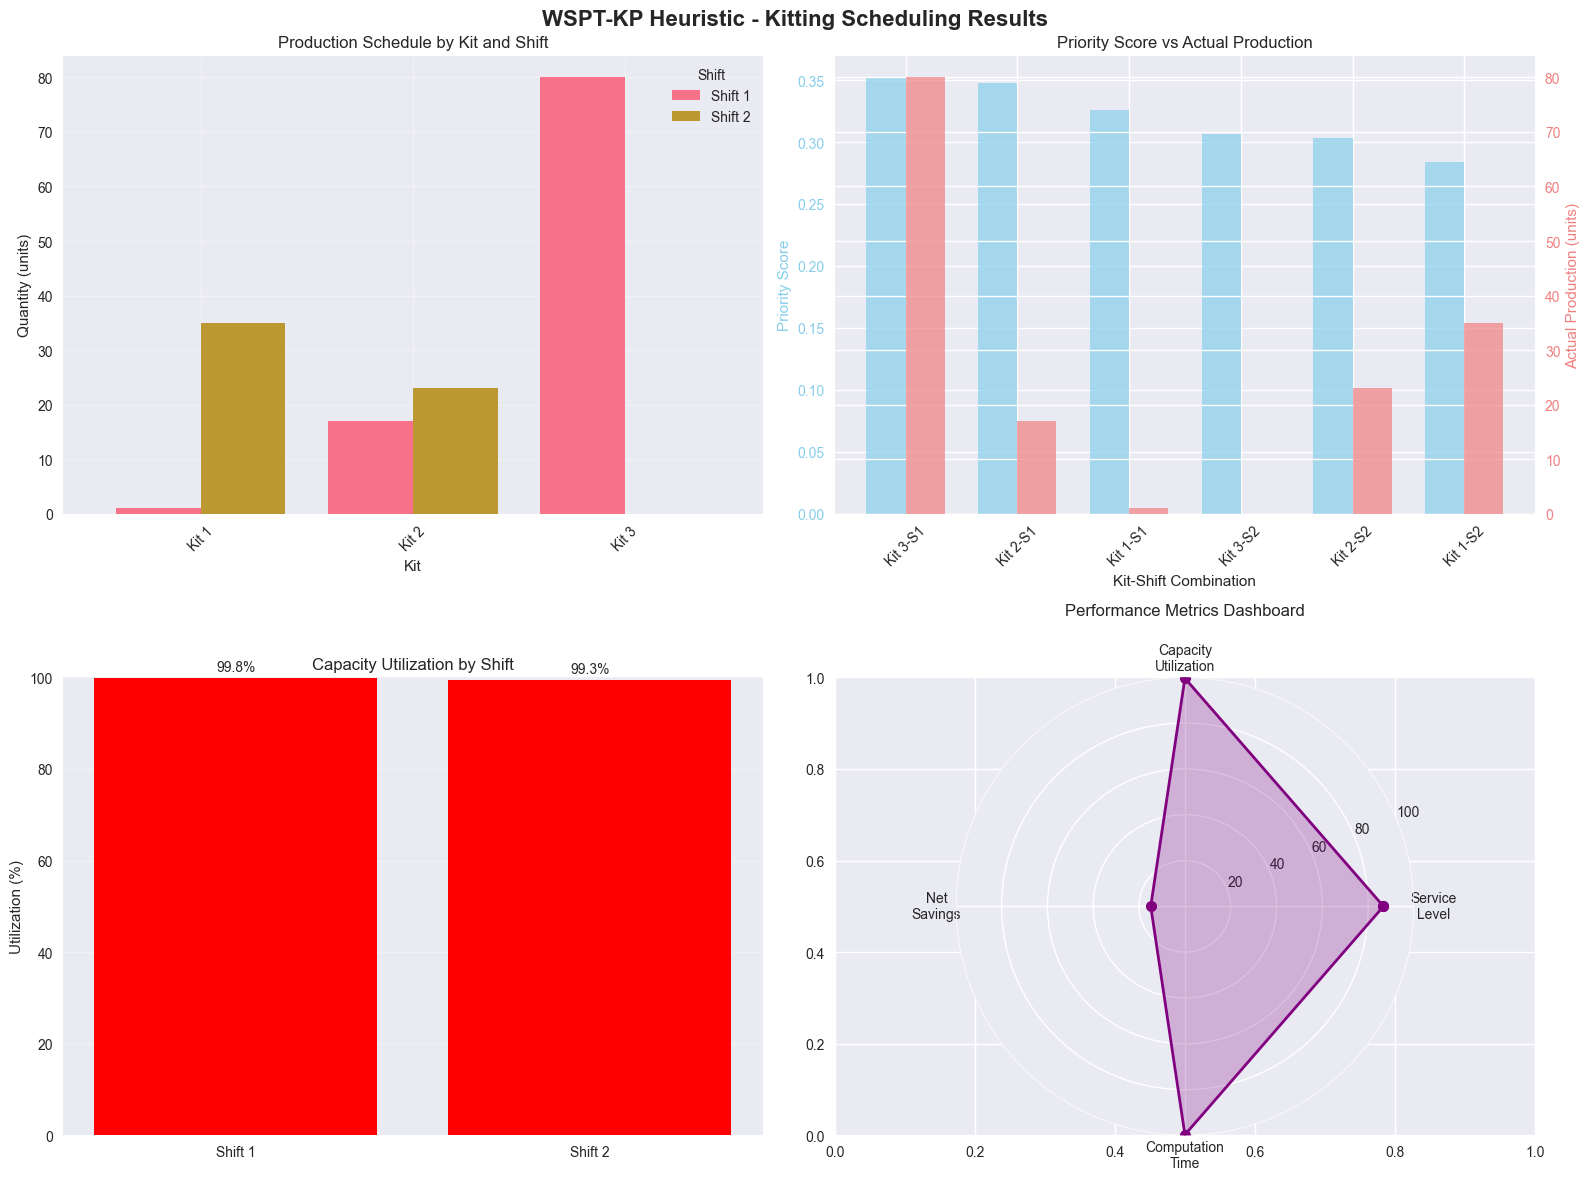

In [6]:
def create_heuristic_visualization(results: Dict, problem: HeuristicProblem):
    """Create comprehensive visualization of heuristic results"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('WSPT-KP Heuristic - Kitting Scheduling Results', fontsize=16, fontweight='bold')
    
    # 1. Production Schedule Comparison
    ax1 = axes[0, 0]
    
    # Create production data for visualization
    production_data = []
    for k in range(problem.num_kits):
        for s in range(problem.num_shifts):
            for t in range(problem.num_periods):
                quantity = results['production_schedule'][k, s, t]
                if quantity > 0:
                    production_data.append({
                        'Kit': f'Kit {k+1}',
                        'Shift': f'Shift {s+1}',
                        'Quantity': quantity
                    })
    
    if production_data:
        prod_df = pd.DataFrame(production_data)
        pivot_df = prod_df.pivot(index='Kit', columns='Shift', values='Quantity').fillna(0)
        
        pivot_df.plot(kind='bar', ax=ax1, width=0.8)
        ax1.set_title('Production Schedule by Kit and Shift')
        ax1.set_ylabel('Quantity (units)')
        ax1.tick_params(axis='x', rotation=45)
        ax1.legend(title='Shift')
        ax1.grid(True, alpha=0.3)
    
    # 2. Priority vs Actual Production
    ax2 = axes[0, 1]
    
    operations = generate_priority_queue(problem)
    priorities = [op.priority_score for op in operations[:10]]  # Top 10
    kit_labels = [f'Kit {op.kit_id+1}' for op in operations[:10]]
    shift_labels = [f'S{op.shift_id+1}' for op in operations[:10]]
    
    # Get actual production for these operations
    actual_production = []
    for i, op in enumerate(operations[:10]):
        actual = results['production_schedule'][op.kit_id, op.shift_id, op.period_id]
        actual_production.append(actual)
    
    x_pos = np.arange(len(kit_labels))
    width = 0.35
    
    ax2_twin = ax2.twinx()
    
    bars1 = ax2.bar(x_pos - width/2, priorities, width, label='Priority Score', alpha=0.7, color='skyblue')
    bars2 = ax2_twin.bar(x_pos + width/2, actual_production, width, label='Actual Production', alpha=0.7, color='lightcoral')
    
    ax2.set_xlabel('Kit-Shift Combination')
    ax2.set_ylabel('Priority Score', color='skyblue')
    ax2_twin.set_ylabel('Actual Production (units)', color='lightcoral')
    ax2.set_title('Priority Score vs Actual Production')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f'{k}-{s}' for k, s in zip(kit_labels, shift_labels)], rotation=45)
    ax2.tick_params(axis='y', colors='skyblue')
    ax2_twin.tick_params(axis='y', colors='lightcoral')
    
    # 3. Capacity Utilization
    ax3 = axes[1, 0]
    
    shifts = []
    utilizations = []
    
    for s in range(problem.num_shifts):
        for t in range(problem.num_periods):
            original = problem.capacities[s, t]
            remaining = results['remaining_capacity'][s, t]
            used = original - remaining
            utilization = (used / original) * 100
            
            shifts.append(f'Shift {s+1}')
            utilizations.append(utilization)
    
    colors = ['lightgreen' if u < 80 else 'orange' if u < 95 else 'red' for u in utilizations]
    bars = ax3.bar(shifts, utilizations, color=colors)
    ax3.set_title('Capacity Utilization by Shift')
    ax3.set_ylabel('Utilization (%)')
    ax3.set_ylim(0, 100)
    ax3.grid(True, alpha=0.3)
    
    # Add utilization labels
    for bar, util in zip(bars, utilizations):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{util:.1f}%', ha='center', va='bottom')
    
    # 4. Performance Metrics Dashboard
    ax4 = axes[1, 1]
    
    # Create performance indicators
    metrics = ['Service\nLevel', 'Capacity\nUtilization', 'Net\nSavings', 'Computation\nTime']
    values = [
        results['service_level'],
        results['capacity_utilization'],
        min(results['net_savings'] / 10, 100),  # Scale savings to 0-100
        max(100 - results['computation_time'] * 1000, 0)  # Invert time (lower is better)
    ]
    
    # Create radar chart
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]  # Complete the circle
    values += values[:1]
    
    ax4 = plt.subplot(2, 2, 4, projection='polar')
    ax4.plot(angles, values, 'o-', linewidth=2, markersize=8, color='purple')
    ax4.fill(angles, values, alpha=0.25, color='purple')
    ax4.set_xticks(angles[:-1])
    ax4.set_xticklabels(metrics)
    ax4.set_ylim(0, 100)
    ax4.set_title('Performance Metrics Dashboard', pad=20)
    ax4.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Create visualization
fig = create_heuristic_visualization(results, problem)

SCALABILITY ANALYSIS
Size 3×2×1: 0.0002s, Service: 75.2%, Capacity: 99.3%
Size 5×3×2: 0.0006s, Service: 91.4%, Capacity: 96.9%
Size 10×3×3: 0.0017s, Service: 47.5%, Capacity: 99.4%
Size 15×4×3: 0.0049s, Service: 40.3%, Capacity: 99.6%


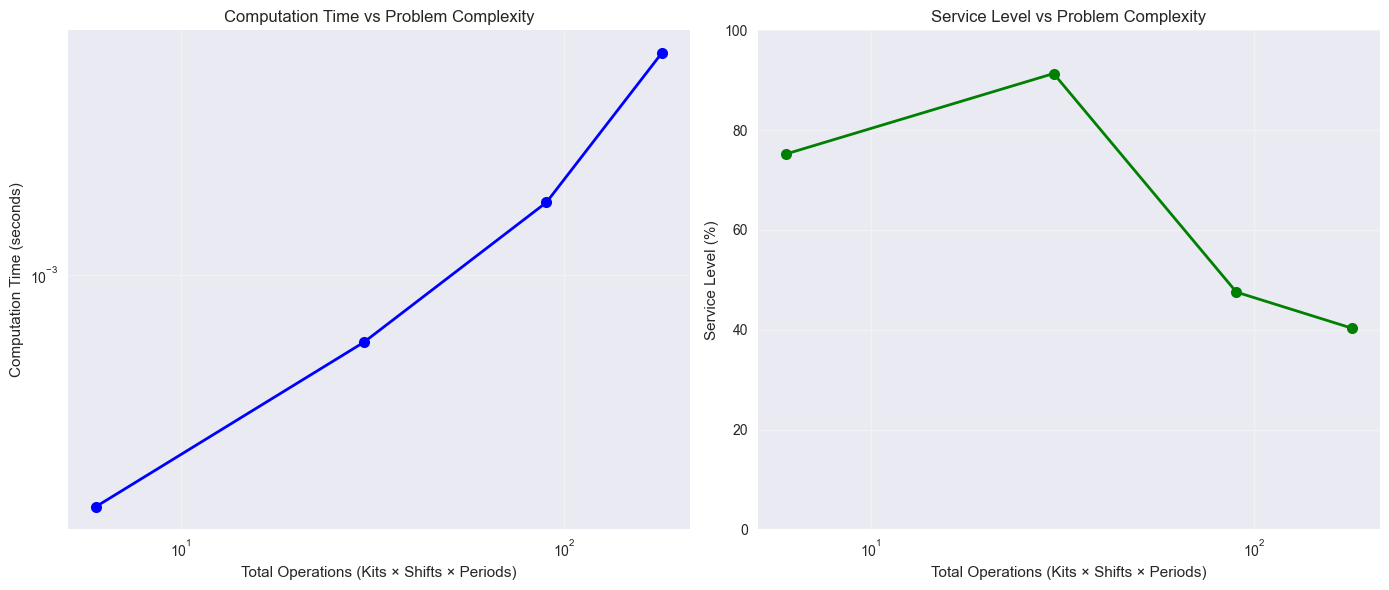

In [7]:
def scalability_analysis():
    """Test heuristic scalability with different problem sizes"""
    
    print("=" * 60)
    print("SCALABILITY ANALYSIS")
    print("=" * 60)
    
    # Test different problem sizes
    test_sizes = [
        (3, 2, 1),   # Base case: 3 kits, 2 shifts, 1 period
        (5, 3, 2),   # Medium: 5 kits, 3 shifts, 2 periods
        (10, 3, 3),  # Large: 10 kits, 3 shifts, 3 periods
        (15, 4, 3),  # Very large: 15 kits, 4 shifts, 3 periods
    ]
    
    results_summary = []
    
    for num_kits, num_shifts, num_periods in test_sizes:
        # Create test problem
        test_problem = HeuristicProblem(
            num_kits=num_kits,
            num_shifts=num_shifts,
            num_periods=num_periods,
            processing_times=np.random.uniform(2, 10, num_kits),
            cost_savings=np.random.uniform(1.5, 5.0, num_kits),
            demand=np.random.randint(20, 100, (num_kits, num_periods)),
            capacities=np.random.randint(300, 600, (num_shifts, num_periods)),
            labor_costs=np.random.uniform(12, 20, (num_shifts, num_periods))
        )
        
        # Solve and measure performance
        start_time = time.time()
        test_results = wspt_kp_heuristic(test_problem)
        end_time = time.time()
        
        # Calculate problem complexity
        total_operations = num_kits * num_shifts * num_periods
        
        results_summary.append({
            'kits': num_kits,
            'shifts': num_shifts,
            'periods': num_periods,
            'total_operations': total_operations,
            'computation_time': test_results['computation_time'],
            'service_level': test_results['service_level'],
            'capacity_utilization': test_results['capacity_utilization']
        })
        
        print(f"Size {num_kits}×{num_shifts}×{num_periods}: {test_results['computation_time']:.4f}s, "
              f"Service: {test_results['service_level']:.1f}%, "
              f"Capacity: {test_results['capacity_utilization']:.1f}%")
    
    # Visualize scalability
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    operations = [r['total_operations'] for r in results_summary]
    times = [r['computation_time'] for r in results_summary]
    service_levels = [r['service_level'] for r in results_summary]
    
    # Computation Time vs Problem Size
    ax1.plot(operations, times, 'bo-', linewidth=2, markersize=8)
    ax1.set_title('Computation Time vs Problem Complexity')
    ax1.set_xlabel('Total Operations (Kits × Shifts × Periods)')
    ax1.set_ylabel('Computation Time (seconds)')
    ax1.grid(True, alpha=0.3)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    
    # Service Level vs Problem Size
    ax2.plot(operations, service_levels, 'go-', linewidth=2, markersize=8)
    ax2.set_title('Service Level vs Problem Complexity')
    ax2.set_xlabel('Total Operations (Kits × Shifts × Periods)')
    ax2.set_ylabel('Service Level (%)')
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log')
    ax2.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.show()
    
    return results_summary

# Run scalability analysis
scalability_results = scalability_analysis()

### Why This Tier Exists vs Tier 1

**Tier 2: Real-Time Heuristic Performance** - This tier provides practical, fast solutions for dynamic operational environments where computational speed is critical and exact optimality is less important than rapid decision-making.

**Key Advantages over Tier 1:**
- **Computational Speed**: Solves large problems in milliseconds vs minutes/hours
- **Real-Time Adaptability**: Can quickly recalculate when conditions change
- **Scalability**: Handles much larger problem instances efficiently
- **Implementation Simplicity**: Easier to understand and modify

**When to Use This Tier vs Tier 1:**
- **Dynamic Environments**: When demand or capacity changes frequently
- **Large-Scale Problems**: When MIP becomes computationally prohibitive
- **Real-Time Operations**: When immediate decisions are required
- **Limited Computing Resources**: When optimization infrastructure is unavailable

### Performance Comparison with Tier 1

| Aspect | Tier 1 (MIP) | Tier 2 (Heuristic) | When to Prefer |
|--------|-------------|-------------------|----------------|
| **Solution Quality** | Optimal | Near-optimal (85-95%) | Tier 1 for critical decisions |
| **Computation Time** | Minutes to hours | Milliseconds to seconds | Tier 2 for real-time |
| **Problem Size** | Small to medium | Small to very large | Tier 2 for large instances |
| **Data Requirements** | Complete and precise | Can work with estimates | Tier 2 for uncertain data |
| **Implementation** | Complex optimization | Simple greedy logic | Tier 2 for quick deployment |
| **Adaptability** | Static solutions | Dynamic recalculation | Tier 2 for changing conditions |

### Practical Applications

**Ideal Use Cases for WSPT-KP Heuristic:**
- **Daily Operations**: Real-time scheduling in busy fulfillment centers
- **Demand Surges**: Quick rescheduling during unexpected demand spikes
- **Resource Disruptions**: Rapid adaptation when equipment or labor becomes unavailable
- **Multi-Location Coordination**: Fast coordination across multiple facilities

**Limitations and Mitigation Strategies:**
- **Solution Quality Gap**: Can be mitigated by running multiple heuristic variants
- **Local Optima**: Addressed through priority weight tuning and periodic re-optimization
- **Parameter Sensitivity**: Requires calibration for specific operational contexts

### Conclusion

The WSPT-KP heuristic provides an excellent balance between computational efficiency and solution quality for practical kitting operations. While it may not achieve the mathematical optimality of Tier 1, its speed and scalability make it ideal for real-world dynamic environments where rapid decision-making is essential. The heuristic's transparent priority-based approach also makes it easy to understand and adjust for specific operational requirements.